# DKO screening — missing gene filter comparison

Compare the SL gene pairs that are lost under two different filtering strategies for the DKO screen:

- **Original filter**: `data/dko_screening/missing_genes_using_original_filter.csv`
- **Stricter filter v2**: `data/dko_screening/missing_genes_using_stricter_filter_v2.csv`

A pair is considered *lost* under a filter if **either** its target or its biomarker gene appears in that filter's missing-gene list.

The candidate pair universe is `notebooks/validation_growth_tissue/coverage_matrix_20251015_ID_mapped.csv` (2000 pairs, sorted by `FDR_MOSA` ascending — so row index = rank, rank 1 = most significant).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

REPO = Path('/home/scai/PhenPred')
PAIRS_FP = REPO / 'notebooks/validation_growth_tissue/coverage_matrix_20251015_ID_mapped.csv'
ORIG_FP  = REPO / 'data/dko_screening/missing_genes_using_original_filter.csv'
STRICT_FP = REPO / 'data/dko_screening/missing_genes_using_stricter_filter_v2.csv'

OUT_DIR = REPO / 'notebooks/validation_growth_tissue'
OUT_DIR.mkdir(exist_ok=True)

## Load data

In [2]:
pairs = pd.read_csv(PAIRS_FP)
pairs['rank'] = np.arange(1, len(pairs) + 1)  # 1 = top (lowest FDR)
pairs['neg_log10_fdr'] = -np.log10(pairs['FDR_MOSA'].clip(lower=1e-300))
print(f'Loaded {len(pairs)} pairs. FDR range: {pairs.FDR_MOSA.min():.2e} .. {pairs.FDR_MOSA.max():.2e}')
pairs.head(3)

Loaded 2000 pairs. FDR range: 1.80e-182 .. 2.46e-02


,target_gene,target_hgnc_id,target_ensembl_gene_id,biomarker_gene,biomarker_hgnc_id,biomarker_ensembl_gene_id,HT-29_Female_Large_Intestine,A375_Female_Skin,Hs-940-T_Male_Skin,MS751_Female_Cervix,CCK-81_Female_Large_Intestine,NCI-H1915_Female_Lung,FDR_MOSA,Beta_MOSA,rank,neg_log10_fdr
0,FAM50A,HGNC:18786,ENSG00000071859,FAM50B,HGNC:18789,ENSG00000145945,0,0,1,0,0,0,1.802213e-182,0.62305,1,181.744194
1,DDX3X,HGNC:2745,ENSG00000215301,DDX3Y,HGNC:2699,ENSG00000067048,0,0,1,0,0,0,2.388087e-127,0.54253,2,126.621950
2,EIF1AX,HGNC:3250,ENSG00000173674,EIF1AY,HGNC:3252,ENSG00000198692,0,0,1,0,0,0,1.891102e-113,0.54443,3,112.723285


In [3]:
orig_missing = pd.read_csv(ORIG_FP)
strict_missing = pd.read_csv(STRICT_FP)

orig_genes = set(orig_missing['gene'].astype(str))
strict_genes = set(strict_missing['gene'].astype(str))

print(f'Original filter: {len(orig_genes)} missing genes')
print(f'Stricter filter v2: {len(strict_genes)} missing genes')
print(f'Intersection: {len(orig_genes & strict_genes)}')
print(f'Only in original:  {len(orig_genes - strict_genes)}')
print(f'Only in stricter:  {len(strict_genes - orig_genes)}')

Original filter: 28 missing genes
Stricter filter v2: 66 missing genes
Intersection: 28
Only in original:  0
Only in stricter:  38


## Flag lost pairs

A pair is lost under a filter if `target_gene` *or* `biomarker_gene` is in that filter's missing-gene set.

In [4]:
def pair_lost(row, missing_set):
    return (row['target_gene'] in missing_set) or (row['biomarker_gene'] in missing_set)

pairs['lost_original'] = pairs.apply(lambda r: pair_lost(r, orig_genes), axis=1)
pairs['lost_stricter'] = pairs.apply(lambda r: pair_lost(r, strict_genes), axis=1)

# Mutually exclusive category for plotting
def classify(r):
    if r['lost_original'] and r['lost_stricter']:
        return 'lost_both'
    if r['lost_stricter']:
        return 'lost_stricter_only'
    if r['lost_original']:
        return 'lost_original_only'
    return 'kept'

pairs['category'] = pairs.apply(classify, axis=1)

summary = pairs['category'].value_counts().reindex(
    ['kept', 'lost_original_only', 'lost_stricter_only', 'lost_both']
).fillna(0).astype(int)
print(summary)

n_lost_orig = int(pairs['lost_original'].sum())
n_lost_strict = int(pairs['lost_stricter'].sum())
print(f"\nTotal lost under original filter:  {n_lost_orig} / {len(pairs)}  ({n_lost_orig/len(pairs):.1%})")
print(f"Total lost under stricter filter:  {n_lost_strict} / {len(pairs)}  ({n_lost_strict/len(pairs):.1%})")

category
kept                  1922
lost_original_only       0
lost_stricter_only      40
lost_both               38
Name: count, dtype: int64

Total lost under original filter:  38 / 2000  (1.9%)
Total lost under stricter filter:  78 / 2000  (3.9%)


## How many top-N pairs are lost?

In [5]:
topN_values = [10, 25, 50, 100, 200, 500, 1000, 2000]
rows = []
for N in topN_values:
    sub = pairs.head(N)
    rows.append({
        'top_N': N,
        'lost_original': int(sub['lost_original'].sum()),
        'lost_stricter': int(sub['lost_stricter'].sum()),
        'lost_original_pct': sub['lost_original'].mean(),
        'lost_stricter_pct': sub['lost_stricter'].mean(),
    })
topN_df = pd.DataFrame(rows)
topN_df

,top_N,lost_original,lost_stricter,lost_original_pct,lost_stricter_pct
0,10,0,0,0.000,0.000
1,25,0,0,0.000,0.000
2,50,0,0,0.000,0.000
3,100,0,0,0.000,0.000
4,200,0,0,0.000,0.000
5,500,10,14,0.020,0.028
6,1000,18,36,0.018,0.036
7,2000,38,78,0.019,0.039


In [6]:
# Export lost-pair tables for reference
lost_orig_df = pairs[pairs['lost_original']][
    ['rank', 'target_gene', 'biomarker_gene', 'FDR_MOSA', 'Beta_MOSA',
     'lost_original', 'lost_stricter']
]
lost_strict_df = pairs[pairs['lost_stricter']][
    ['rank', 'target_gene', 'biomarker_gene', 'FDR_MOSA', 'Beta_MOSA',
     'lost_original', 'lost_stricter']
]

lost_orig_df.to_csv(OUT_DIR / 'lost_pairs_original_filter.csv', index=False)
lost_strict_df.to_csv(OUT_DIR / 'lost_pairs_stricter_filter_v2.csv', index=False)
print(f'Wrote {len(lost_orig_df)} rows -> lost_pairs_original_filter.csv')
print(f'Wrote {len(lost_strict_df)} rows -> lost_pairs_stricter_filter_v2.csv')
lost_strict_df.head(10)

Wrote 38 rows -> lost_pairs_original_filter.csv
Wrote 78 rows -> lost_pairs_stricter_filter_v2.csv


,rank,target_gene,biomarker_gene,FDR_MOSA,Beta_MOSA,lost_original,lost_stricter
228,229,AP3B1,CIBAR1,4.730325e-07,0.21703,True,True
244,245,HNRNPH1,MARCHF8,9.494190e-07,0.15500,True,True
291,292,ADSS2,ADSS1,3.440323e-06,0.15789,True,True
297,298,PEDS1,DOCK7,4.150605e-06,0.16547,True,True
328,329,NAA10,XAGE1B,6.808413e-06,0.17855,True,True
333,334,USP28,MARCHF9,7.675329e-06,0.16023,True,True
335,336,SLC7A6OS,H2AC6,7.979385e-06,0.17073,True,True
340,341,DDX19A,FAHD2B,9.232913e-06,0.17512,False,True
388,389,CLSPN,F8A3,3.001409e-05,0.14004,False,True
435,436,DDX21,UPK3BL1,5.674391e-05,0.14069,False,True


## Plot — where in the ranking are the lost pairs?

Three-panel figure:

1. **Top** — every pair plotted as rank vs `-log10(FDR)`. Kept pairs are light grey; lost pairs are coloured by filter. If a pair is lost by *both* filters, the stricter-filter marker is drawn on top with a darker outline.
2. **Middle** — rug / strip plot showing rank positions of lost pairs for each filter.
3. **Bottom** — cumulative count of lost pairs as a function of rank (i.e. how many of the top-N are lost, as N grows).

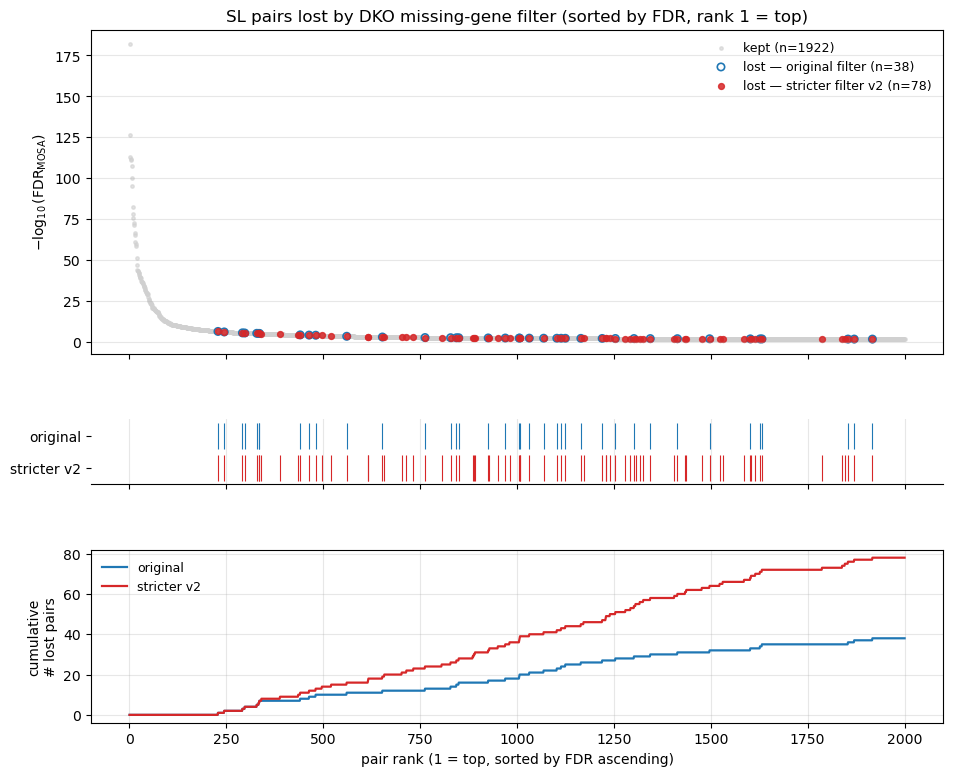

In [7]:
COLOR_KEPT    = '#d0d0d0'
COLOR_ORIG    = '#1f77b4'  # blue
COLOR_STRICT  = '#d62728'  # red
COLOR_BOTH    = '#6a1b9a'  # purple (for reference; stricter implies it by construction below)

fig, axes = plt.subplots(
    3, 1,
    figsize=(11, 9),
    gridspec_kw={'height_ratios': [3, 0.6, 1.6], 'hspace': 0.35},
    sharex=True,
)

# ---- Panel 1: scatter rank vs -log10(FDR) ----
ax = axes[0]
kept = pairs[pairs['category'] == 'kept']
ax.scatter(kept['rank'], kept['neg_log10_fdr'],
           s=6, c=COLOR_KEPT, alpha=0.6, label=f'kept (n={len(kept)})', rasterized=True)

lost_orig_pts = pairs[pairs['lost_original']]
ax.scatter(lost_orig_pts['rank'], lost_orig_pts['neg_log10_fdr'],
           s=28, facecolors='none', edgecolors=COLOR_ORIG, linewidths=1.2,
           label=f'lost — original filter (n={n_lost_orig})')

lost_strict_pts = pairs[pairs['lost_stricter']]
ax.scatter(lost_strict_pts['rank'], lost_strict_pts['neg_log10_fdr'],
           s=18, c=COLOR_STRICT, alpha=0.85,
           label=f'lost — stricter filter v2 (n={n_lost_strict})')

ax.set_ylabel(r'$-\log_{10}$(FDR$_{\mathrm{MOSA}}$)')
ax.set_title('SL pairs lost by DKO missing-gene filter (sorted by FDR, rank 1 = top)')
ax.legend(loc='upper right', frameon=False, fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ---- Panel 2: rug plot of lost-pair rank positions ----
ax = axes[1]
ax.vlines(lost_orig_pts['rank'], 0.55, 0.95, colors=COLOR_ORIG, linewidth=0.8, label='original')
ax.vlines(lost_strict_pts['rank'], 0.05, 0.45, colors=COLOR_STRICT, linewidth=0.8, label='stricter v2')
ax.set_yticks([0.25, 0.75])
ax.set_yticklabels(['stricter v2', 'original'])
ax.set_ylim(0, 1)
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.3)
for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)

# ---- Panel 3: cumulative count of lost pairs vs rank ----
ax = axes[2]
cum_orig = pairs['lost_original'].cumsum().values
cum_strict = pairs['lost_stricter'].cumsum().values
ax.plot(pairs['rank'], cum_orig, color=COLOR_ORIG, lw=1.6, label='original')
ax.plot(pairs['rank'], cum_strict, color=COLOR_STRICT, lw=1.6, label='stricter v2')
ax.set_xlabel('pair rank (1 = top, sorted by FDR ascending)')
ax.set_ylabel('cumulative\n# lost pairs')
ax.legend(loc='upper left', frameon=False, fontsize=9)
ax.grid(alpha=0.3)

fig.savefig(OUT_DIR / 'lost_pairs_filter_comparison.png', dpi=250, bbox_inches='tight')
fig.savefig(OUT_DIR / 'lost_pairs_filter_comparison.pdf', bbox_inches='tight')
plt.show()

## Summary

Key things to read off the plot:

- The **rug panel** immediately shows whether lost pairs are clustered at the top (left) of the ranking or spread across the whole list.
- The **cumulative curve** rising steeply near the left-hand side would mean the filter is disproportionately removing high-confidence pairs; a roughly linear rise means losses are ~uniform across ranks.
- The open blue markers vs solid red markers in the scatter make it easy to see pairs that the stricter filter *additionally* removes compared to the original.